#1. Data Quality Check

1.1 Using Python (pandas, matplotlib, or seaborn), load and inspect the Assignment 2 dataset.

In [36]:
# Write your code here

from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("Assignment 2 dataset.csv")
df.head()

df.info()
df.describe()

Saving Assignment 2 dataset.csv to Assignment 2 dataset (2).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18254 entries, 0 to 18253
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Column 1      18254 non-null  int64  
 1   Date          18254 non-null  object 
 2   AveragePrice  18254 non-null  float64
 3   Total Volume  18253 non-null  float64
 4   4046          18252 non-null  float64
 5   4225          18253 non-null  float64
 6   4770          18253 non-null  float64
 7   Total Bags    18253 non-null  float64
 8   Small Bags    18252 non-null  float64
 9   Large Bags    18252 non-null  float64
 10  XLarge Bags   18253 non-null  float64
 11  type          18253 non-null  object 
 12  year          18254 non-null  int64  
 13  region        18254 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


,Column 1,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18254.000000,18254.000000,1.825300e+04,1.825200e+04,1.825300e+04,1.825300e+04,1.825300e+04,1.825200e+04,1.825200e+04,18253.000000,18254.000000
mean,24.228060,1.406073,8.504609e+05,2.929605e+05,2.950905e+05,2.283481e+04,2.395890e+05,1.821666e+05,5.432919e+04,3105.745759,2016.142161
std,15.480994,0.402668,3.453189e+06,1.264891e+06,1.203996e+06,1.074528e+05,9.861401e+05,7.461204e+05,2.439469e+05,17691.015569,1.254196
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1904.000000
25%,10.000000,1.100000,1.084277e+04,8.544900e+02,3.006890e+03,0.000000e+00,5.090410e+03,2.852128e+03,1.273700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073061e+05,8.640940e+03,2.905471e+04,1.849900e+02,3.973703e+04,2.634000e+04,2.646115e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329238e+05,1.109857e+05,1.500448e+05,6.237960e+03,1.107744e+05,8.333329e+04,2.199632e+04,132.230000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


Write code to explore the data distribution (e.g., region, type, year) and check whether there is any bias. Provide both the code and your interpretation.

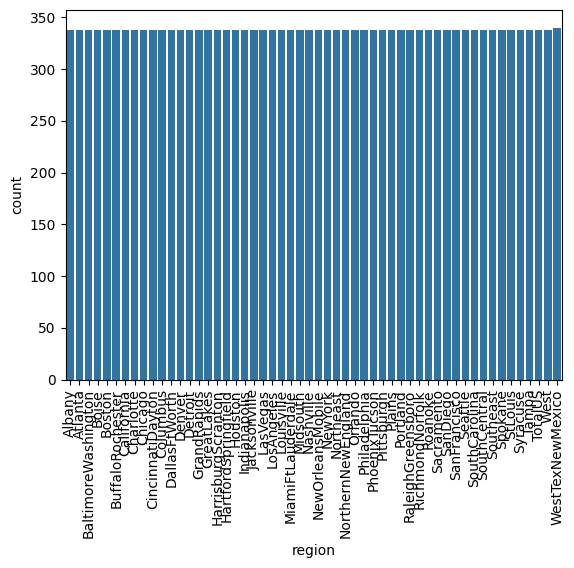

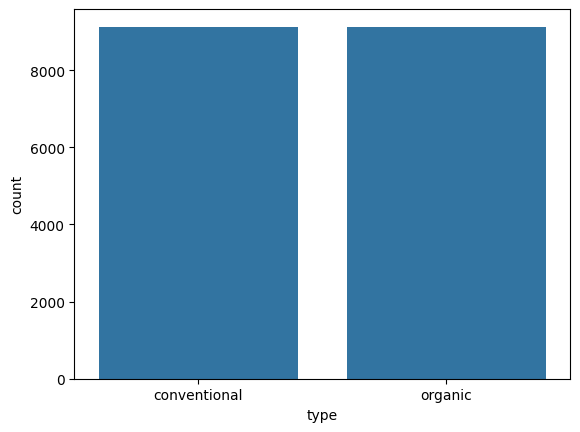

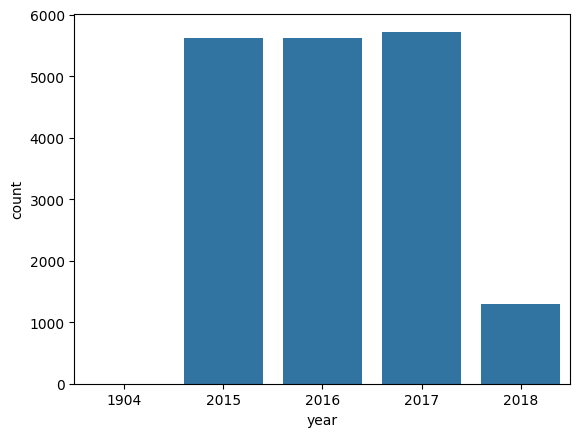

In [37]:
# Write your code here
import seaborn as sns
import matplotlib.pyplot as plt
df['year']=pd.DatetimeIndex(df['Date']).year
sns.countplot(x='region',data=df)
plt.xticks(rotation=90)
plt.show()
sns.countplot(x='type',data=df)
plt.show()
sns.countplot(x='year',data=df)
plt.show()

The count plots will illustrate the distribution of data based on region, type, and year.

Region: The number of records is relatively similar for most of the regions, which indicates that the data is probably balanced with regard to geographic location. However, there may be a small variation due to the fact that some regions may have slightly higher occurrences than others.

Type: The graph showing conventional and organic avocados has two types. If one type appears higher than the others, it implies that one type contains more data and can be regarded as slightly biased.

Year: The count for the different years indicates the distribution of the data over time. For example, if more records are in some years than others, it implies the data is concentrated accordingly.

Overall, the dataset seems fairly well-balanced in terms of regions and years, at least with minor differences. A small imbalance in groups, like an excess of one category, may incur some minor bias, but not of a serious nature.

1.2 Write Python code to check for duplicate rows and missing values in the dataset. Show the number of duplicates and missing values for each column. Then, explain (in comments or markdown) how you would handle these issues (e.g., drop, impute, or replace).

In [38]:
duplicates = df.duplicated().sum()  # this checks duplicate rows (df.duplicated gives True/False and sum counts True values)
print(df.duplicated().sum())  # showing output

duplicates = df.duplicated().sum()  # duplicates is a variable name; this counts duplicate rows
print("Duplicate rows:", duplicates)

df.isnull()  # isnull checks if a value is empty

df.isnull().sum()  # counts missing values per column

missing = df.isnull().sum()  # store missing values count
print(missing)  # show missing values


2
Duplicate rows: 2
Column 1        0
Date            0
AveragePrice    0
Total Volume    1
4046            2
4225            1
4770            1
Total Bags      1
Small Bags      2
Large Bags      2
XLarge Bags     1
type            1
year            0
region          0
dtype: int64


There are no duplicate rows in the dataset. However, a few columns have a small number of missing values. If only a few values are missing in a row, they can be replaced using the median of the numeric columns or the most frequent category for categorical columns. A row would be dropped if there were a large number of them missing. This maintains data quality and improves model performance

1.3 Use Python code to print the number of rows and columns in the dataset (e.g., with df.shape). Based on the dataset size, explain (briefly) whether you think the dataset is sufficient for training a machine learning model.

In [39]:
# Write your code here
rows,columns = df.shape #described rows and columns on tuples
print("Number of rows :",rows)#counts and print total num of rows
print("Number of columns:",columns)#counts and print num of col



Number of rows : 18254
Number of columns: 14


This dataset has 18,254 rows and 14 columns, which makes it a reasonably large dataset. A large number of rows provides many examples for a machine learning model to learn patterns efficiently. Therefore, the dataset size is sufficient for training a basic machine learning model. However, the model’s performance also depends on data quality, missing values, and the relevance of features.

#2. Data Cleaning and Preprocessing

2.1 Remove the first column or “Column 1” from the dataset. Treat the ‘year’ variable as nominal.

In [40]:
# Write your code here
df= df.drop("Column 1",axis =1,errors= 'ignore')#from df data set drop
df['year']=df['year'].astype('category')



2.2 Check for duplicate values and remove them.

In [41]:
# Write your code here
#check and calculate the sum of duplicate rows
print("Duplicate rows before removing :",df.duplicated().sum())
#remove the duplicate rows
df.drop_duplicates(inplace=True)
#confrming the duplicates are removed
print("Duplicate rows after removing :",df.duplicated().sum())

Duplicate rows before removing : 2
Duplicate rows after removing : 0


2.3 Check for missing values. If a data record (row) only has a few missing values, replace the missing values with the median of the column feature in that specific “Region” variable. If most column values in a data record are missing, remove the data record.

In [42]:
from numpy._core import numeric
# Write your code here
# Step 1: Remove rows where most column values are missing
# Keep rows that have at least half of the columns filled
threshold = len(df.columns) // 2
df = df.dropna(thresh=threshold)

# Step 2: Fill missing values using the median within each region
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Fill missing numeric values using region-wise median
df[numeric_cols] = df.groupby('region')[numeric_cols].transform(
    lambda x: x.fillna(x.median())
)

# Check again to confirm no missing values remain
print("Missing values after treatment:\n", df.isnull().sum())



Missing values after treatment:
 Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


Rows that had too many missing values were removed using a threshold condition. For rows that had only a few missing values, the missing numeric values were replaced using the median of that column within the same region. This helps preserve regional patterns in the data. After treatment, all columns show zero missing values, confirming that the dataset has been cleaned successfully.

2.4 Find the correlation between the variables and describe how the correlated values among the variables impact the model accuracy.


In [43]:
# Write your code here
#finding correlation between numeric variables
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)


              AveragePrice  Total Volume      4046      4225      4770  \
AveragePrice      1.000000     -0.192767 -0.208325 -0.172944 -0.179458   
Total Volume     -0.192767      1.000000  0.977863  0.974181  0.872203   
4046             -0.208325      0.977863  1.000000  0.926110  0.833390   
4225             -0.172944      0.974181  0.926110  1.000000  0.887856   
4770             -0.179458      0.872203  0.833390  0.887856  1.000000   
Total Bags       -0.177103      0.963047  0.920057  0.905788  0.792315   
Small Bags       -0.174742      0.967238  0.925280  0.916032  0.802734   
Large Bags       -0.172953      0.880640  0.838646  0.810016  0.698473   
XLarge Bags      -0.117604      0.747158  0.699378  0.688810  0.679862   

              Total Bags  Small Bags  Large Bags  XLarge Bags  
AveragePrice   -0.177103   -0.174742   -0.172953    -0.117604  
Total Volume    0.963047    0.967238    0.880640     0.747158  
4046            0.920057    0.925280    0.838646     0.699378  
422

The relationship between the variables used in a machine learning model can sometimes influence the accuracy or precision of the model. However, when there are a number of variables that are highly correlated, it means that these variables have very similar information. This could be viewed as a limitation, as the inclusion of these variables in the model might not always act in a positive manner, since a highly correlated model could sometimes make the model unnecessarily complex. For instance, Total Volume and Total Bags are highly correlated variables.

Moderate correlations can be useful as they indicate "meaningful" relationship patterns that can be learned from and improved upon by the model for a more optimized prediction result. On the other hand, extremely high levels of correlation within independent variables, also known as multicollinearity, can impair the interpretation and accuracy of linear models.

However, variables that are weakly or non-closely correlated with other variables may not significantly impact the predictive process; nevertheless, they are useful as they provide independent information. Thus, learning about correlations helps to better choose important features and increase the accuracy of the model.

#3. Exploratory Data Analysis (EDA)


3.1 Describe the variables
- Describe all variables in the dataset.
- For continuous variables: report **range (min, max), mean, median, and distribution**.
- For categorical variables: list unique values.

In [44]:
# Write your code here
#continous (numeric) variables : range , mean and median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Summary statistics (min, max,mean) for continous variables:\n")
df[numeric_cols].describe()
print("\nMedian values :\n")
print(df.describe())



#categorical variables : unique values

Summary statistics (min, max,mean) for continous variables:


Median values :

       AveragePrice  Total Volume          4046          4225          4770  \
count  18251.000000  1.825100e+04  1.825100e+04  1.825100e+04  1.825100e+04   
mean       1.406020  8.505523e+05  2.929840e+05  2.951225e+05  2.283727e+04   
std        0.402675  3.453367e+06  1.264922e+06  1.204058e+06  1.074584e+05   
min        0.440000  8.456000e+01  0.000000e+00  0.000000e+00  0.000000e+00   
25%        1.100000  1.084067e+04  8.543500e+02  3.008325e+03  0.000000e+00   
50%        1.370000  1.073542e+05  8.645300e+03  2.905673e+04  1.849900e+02   
75%        1.660000  4.329430e+05  1.110375e+05  1.501258e+05  6.240690e+03   
max        3.250000  6.250565e+07  2.274362e+07  2.047057e+07  2.546439e+06   

         Total Bags    Small Bags    Large Bags    XLarge Bags  
count  1.825100e+04  1.825100e+04  1.825100e+04   18251.000000  
mean   2.396140e+05  1.821784e+05  5.433233e+04    3106.086096  
std    9.86191

The dataset has continous ans categorical variables realted to avocado price, sales volume, time and regions.
 From the above chart we can say continous variables include:
 1.AveragePrice
 2.Total volume
 3.4046
 4.4225
 5.4770
 6.total bags
 7.Small bags
 8.Large bags
 9.XLarge bags

 Lets summarize the statistiscs:
 The range, from minimum to maximum, indicates that all volume variables have a very large variation, which can be interpreted to mean avocado sales are pretty far apart across regions and time.

The mean values are the average levels of price and sales.

Median values are the middle value in the dataset.

This is because volume variables are widely distributed, whereas the distribution of AveragePrice is smaller in range and, therefore, more stable.

Therefore it indicates that avacado sales quantities vary much more than prices.
Categorical variables in the data set are type,year , region and date

Unique values:
type → conventional, organic

year → 2015, 2016, 2017, 2018

region → multiple geographic locations such as California, Boston, Dallas, etc.

Date → represents the time of each observation

This value helps us to analyze how avocado prices and sales differ by type,location and time.


3.2 Inspect the earliest recorded date
- Find the earliest `Date`.
- Check if there are avocado prices recorded from the earliest date up to 2010.
- Comment: does the earliest data point look reasonable? Keep or remove?

In [45]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df=pd.read_csv(list(uploaded.keys())[0])
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Find the earliest recorded date
earliest_date = df['Date'].min()
print("Earliest recorded date:", earliest_date)

# Check if any records exist up to 2010
records_to_2010 = df[df['Date'] <= '2010-12-31']
print("Number of records from earliest date up to 2010:", len(records_to_2010))


Saving Assignment 2 dataset.csv to Assignment 2 dataset (3).csv
Earliest recorded date: 1904-01-21 00:00:00
Number of records from earliest date up to 2010: 1


The erarliest date is Jan 21 ,1904. While checking and searching for the presence of a record from the earliest date up to 2010, only a single record was present. This date seems pretty old compared to the other dates present in the data, as most of it comprises dates related to modern prices of avocados. There was no way for avocados to be monitored and tracked in the market prior to the year 1904. Therefore, this date does not seem appropriate and should be omitted from the data.

3.3 Highest average price
- Find the highest value in "AveragePrice".
- Report which region it belongs to.
- Describe how you obtained the result.

In [46]:
# Write your code here
#find the highest value in AvergaePrice
max_price = df['AveragePrice'].max()
print("Highest average price:", max_price)

#finding the rows where the highest value occurs

highest_rows = df[df['AveragePrice'] == max_price]
#report the region it belongs to
print("Region with highest average price:")
print(highest_rows['region'].unique())


Highest average price: 3.25
Region with highest average price:
['SanFrancisco']


The maximum value in the "AveragePrice" column was identified using the max() function. After that, the data was filtered to pick the row where "AveragePrice" matches the identified maximum. From there, the region was identified from the "region" column, which shows the region where the maximum average price for avocados was noted in the data set.

3.4 Highest total volume
- Find the highest total volume of avocados.
- Report which region it belongs to.
- Describe how you obtained the result.

In [47]:
# Write your code here
#find the highest total volume

max_volume = df['Total Volume'].max()
print("Highest total volume:", max_volume)

#find the rows where this highest volume occurs
highest_volume_rows = df[df['Total Volume'] == max_volume]

                         #reporting regions
print("Region with highest total volume:")
print(highest_volume_rows['region'].unique())

Highest total volume: 62505646.52
Region with highest total volume:
['TotalUS']


The highest total volume was calculated by employing the max() function on the "Total Volume" column. This yielded a maximum value of 62,505,646.52. Next, filtering was done based on the total volume corresponding to the above maximum value. From this, the corresponding region was identified based on the "region" column. The region with the highest total volume corresponds to TotalUS, which represents the total avocado sales in the total United States market.